# Arabic Medical QA
**Problems to solve:**
1. Inconsistent label names (spaces, dashes, underscores)
2. Mislabeled samples → Cleanlab
3. Class imbalance → Class Weights (inside model)

**After this notebook:** use `train_clean.csv` for modeling.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install cleanlab pyarabic -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.1/306.1 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 12.9 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import re
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

DATA_PATH = "/content/drive/MyDrive/Arabic_Medical _Q&A"

train_df = pd.read_csv(f'{DATA_PATH}/train.csv')
val_df   = pd.read_csv(f'{DATA_PATH}/val.csv')
test_df  = pd.read_csv(f'{DATA_PATH}/test.csv')

print(f"Train:      {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"Test:       {len(test_df):,}")
print(f"Total:      {len(train_df)+len(val_df)+len(test_df):,}")
print(f"\nColumns: {train_df.columns.tolist()}")
display(train_df.head(5))

Train:      52,758
Validation: 17,586
Test:       17,586
Total:      87,930

Columns: ['question', 'answer', 'label']


,question,answer,label
0,\nما هي مميزات و عيوب الدواء جلوكوفانس 500 5 و...,\n\nلكل علاج ايجابيته وسلبياته والتي تعتمد على...,الدم
1,\nاليك نتيجة تحليل هرمونات الغدة الدرقية علما ...,\n\nنعم. يجب تخفيض الجرعة، الا اذا كان سبب است...,الاورام-الخبيثة-والحميدة
2,\nحلول منزلية لأعراض ارتفاع ضغط الدم,\n\nيفضل عدم الاستغناء عن العلاج الدوائي لمرضى...,جراحة-عامة
3,\nعملت عملية دوالي الساقين قسطرة الليزر من شهر...,\n\nراجع طبيبك من اجري الجراحه افضل من يجيب لا...,أمراض-الجهاز-التنفسي
4,\nما حقيقة ان تمرين العضلة النعلية يخفض السكر ...,\n\nإذا قصدت تدليك العضلة فهذا كلام غير صحيح ....,مرض-السكري


## 2. Data Exploration (EDA)

### 2.1 Null Values

In [4]:
print("=" * 55)
print("NULL VALUES")
print("=" * 55)
for df, name in [(train_df,'Train'),(val_df,'Val'),(test_df,'Test')]:
    nulls = df.isnull().sum()
    total = nulls.sum()
    print(f"\n{name} (total nulls: {total}):")
    print(nulls)

NULL VALUES

Train (total nulls: 101):
question      0
answer      101
label         0
dtype: int64

Val (total nulls: 39):
question     0
answer      39
label        0
dtype: int64

Test (total nulls: 34):
question     0
answer      34
label        0
dtype: int64


### 2.2 Duplicate Rows

In [5]:
print("=" * 55)
print("DUPLICATES")
print("=" * 55)
for df, name in [(train_df,'Train'),(val_df,'Val'),(test_df,'Test')]:
    dups = df.duplicated(subset=['question','answer']).sum()
    pct  = dups/len(df)*100
    print(f"{name}: {dups:,} duplicates ({pct:.2f}%)")

DUPLICATES
Train: 21,031 duplicates (39.86%)
Val: 6,951 duplicates (39.53%)
Test: 7,047 duplicates (40.07%)


### 2.3 Text Length Distribution

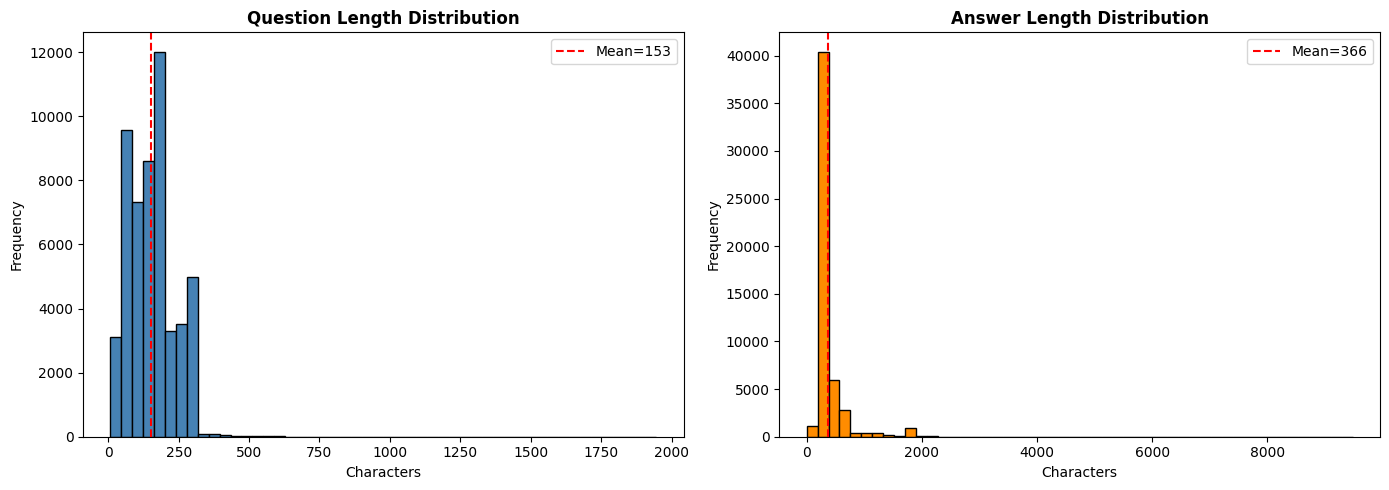

Question — Mean: 153 | Max: 1946 | Min: 8
Answer   — Mean: 366 | Max: 9485 | Min: 0


In [6]:
for df in [train_df, val_df, test_df]:
    df['q_len'] = df['question'].fillna('').str.len()
    df['a_len'] = df['answer'].fillna('').str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['q_len'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Question Length Distribution', fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')
axes[0].axvline(train_df['q_len'].mean(), color='red', linestyle='--',
                label=f"Mean={train_df['q_len'].mean():.0f}")
axes[0].legend()

axes[1].hist(train_df['a_len'], bins=50, color='darkorange', edgecolor='black')
axes[1].set_title('Answer Length Distribution', fontweight='bold')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Frequency')
axes[1].axvline(train_df['a_len'].mean(), color='red', linestyle='--',
                label=f"Mean={train_df['a_len'].mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/eda_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Question — Mean: {train_df['q_len'].mean():.0f} | Max: {train_df['q_len'].max()} | Min: {train_df['q_len'].min()}")
print(f"Answer   — Mean: {train_df['a_len'].mean():.0f} | Max: {train_df['a_len'].max()} | Min: {train_df['a_len'].min()}")

### 2.4 Label Distribution (Before Cleaning)

In [7]:
label_counts_raw = train_df['label'].value_counts()

print(f"Unique labels (raw): {train_df['label'].nunique()}")
print(f"\nTop 10:")
for i,(l,c) in enumerate(label_counts_raw.head(10).items()):
    print(f"  {i+1:2}. {str(l):<45} {c:>6} samples")
print(f"\nBottom 10:")
for i,(l,c) in enumerate(label_counts_raw.tail(10).items()):
    print(f"  {i+1:2}. {str(l):<45} {c:>6} samples")

print(f"\nLargest:         {label_counts_raw.iloc[0]:,} samples")
print(f"Smallest:        {label_counts_raw.iloc[-1]:,} samples")
print(f"Imbalance ratio: {label_counts_raw.iloc[0]/label_counts_raw.iloc[-1]:.0f}x")

Unique labels (raw): 37

Top 10:
   1. الاورام-الخبيثة-والحميدة                        9536 samples
   2. جراحة-عامة                                      9439 samples
   3. امراض-الغدد-الصماء                              6723 samples
   4. مرض-السكري                                      5615 samples
   5. امراض-الجهاز-التنفسي                            4476 samples
   6. ارتفاع-ضغط-الدم                                 3908 samples
   7. جراحة-العظام                                    2499 samples
   8. امراض-الدم                                      1720 samples
   9. الغدد-الصماء                                    1068 samples
  10. السكري                                           936 samples

Bottom 10:
   1. أمراض_الغدد_الصماء                                93 samples
   2. جراحة_العظام                                      90 samples
   3. أمراض الغدد الصماء                                87 samples
   4. أمراض_الجهاز_التنفسي                              59 samples
   5. جراحة العظا

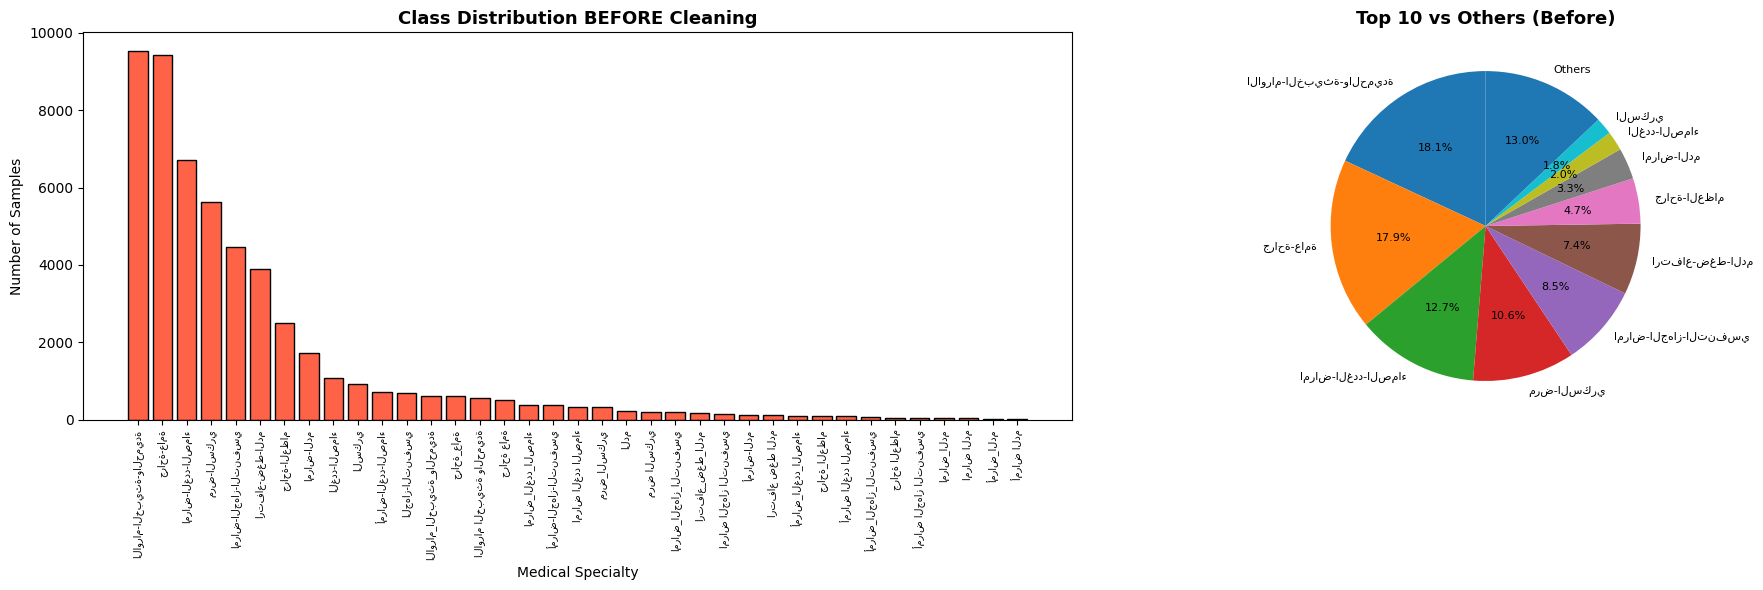

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].bar(range(len(label_counts_raw)), label_counts_raw.values,
            color='tomato', edgecolor='black')
axes[0].set_title('Class Distribution BEFORE Cleaning', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Medical Specialty')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xticks(range(len(label_counts_raw)))
axes[0].set_xticklabels([str(l) for l in label_counts_raw.index], rotation=90, fontsize=7)

top10  = label_counts_raw.head(10)
others = label_counts_raw.iloc[10:].sum()
axes[1].pie(list(top10.values)+[others],
            labels=[str(l) for l in top10.index]+['Others'],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize':8})
axes[1].set_title('Top 10 vs Others (Before)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/eda_before_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 EDA Summary

In [9]:
total_nulls = sum(df.isnull().sum().sum() for df in [train_df,val_df,test_df])
total_dups  = sum(df.duplicated(subset=['question','answer']).sum()
                  for df in [train_df,val_df,test_df])

print("=" * 55)
print("EDA SUMMARY — ISSUES FOUND")
print("=" * 55)
print(f"1. Null values:              {total_nulls}")
print(f"2. Duplicate rows:           {total_dups}")
print(f"3. Inconsistent label names: YES")
print(f"4. Mislabeled samples:       YES (to detect with Cleanlab)")
print(f"5. Class imbalance:          {label_counts_raw.iloc[0]/label_counts_raw.iloc[-1]:.0f}x ratio")
print(f"6. Unique labels (raw):      {train_df['label'].nunique()}")

EDA SUMMARY — ISSUES FOUND
1. Null values:              174
2. Duplicate rows:           35029
3. Inconsistent label names: YES
4. Mislabeled samples:       YES (to detect with Cleanlab)
5. Class imbalance:          1192x ratio
6. Unique labels (raw):      37


## 3. Data Cleaning

### 3.1 Drop Nulls & Duplicates

In [10]:
before = {n: len(df) for df,n in [(train_df,'train'),(val_df,'val'),(test_df,'test')]}

for df in [train_df, val_df, test_df]:
    df.dropna(subset=['question','answer','label'], inplace=True)
    df.drop_duplicates(subset=['question','answer'], inplace=True)
    df.reset_index(drop=True, inplace=True)

after = {n: len(df) for df,n in [(train_df,'train'),(val_df,'val'),(test_df,'test')]}

print("Rows after cleaning:")
for name in before:
    removed = before[name]-after[name]
    print(f"  {name}: {before[name]:,} → {after[name]:,}  (removed {removed:,})")

Rows after cleaning:
  train: 52,758 → 31,626  (removed 21,132)
  val: 17,586 → 10,596  (removed 6,990)
  test: 17,586 → 10,505  (removed 7,081)


### 3.2 Normalize Label Names

In [11]:
def normalize_label(label):
    if not isinstance(label, str):
        return label
    label = re.sub('[إأآا]', 'ا', label)        # normalize alef
    label = re.sub(r'[-\s_]+', '_', label)      # unify separators
    label = label.strip('_')
    return label

print(f"Labels BEFORE normalization: {train_df['label'].nunique()}")
print(sorted(train_df['label'].unique()))

for df in [train_df, val_df, test_df]:
    df['label'] = df['label'].apply(normalize_label)

print(f"\nLabels AFTER normalization: {train_df['label'].nunique()}")
print(sorted(train_df['label'].unique()))

Labels BEFORE normalization: 37
['أمراض الجهاز التنفسي', 'أمراض الدم', 'أمراض الغدد الصماء', 'أمراض-الجهاز-التنفسي', 'أمراض-الدم', 'أمراض-الغدد-الصماء', 'أمراض_الجهاز_التنفسي', 'أمراض_الدم', 'أمراض_الغدد_الصماء', 'ارتفاع ضغط الدم', 'ارتفاع-ضغط-الدم', 'ارتفاع_ضغط_الدم', 'الاورام الخبيثة والحميدة', 'الاورام-الخبيثة-والحميدة', 'الاورام_الخبيثة_والحميدة', 'الجهاز-التنفسي', 'الدم', 'السكري', 'الغدد-الصماء', 'امراض الجهاز التنفسي', 'امراض الدم', 'امراض الغدد الصماء', 'امراض-الجهاز-التنفسي', 'امراض-الدم', 'امراض-الغدد-الصماء', 'امراض_الجهاز_التنفسي', 'امراض_الدم', 'امراض_الغدد_الصماء', 'جراحة العظام', 'جراحة عامة', 'جراحة-العظام', 'جراحة-عامة', 'جراحة_العظام', 'جراحة_عامة', 'مرض السكري', 'مرض-السكري', 'مرض_السكري']

Labels AFTER normalization: 12
['ارتفاع_ضغط_الدم', 'الاورام_الخبيثة_والحميدة', 'الجهاز_التنفسي', 'الدم', 'السكري', 'الغدد_الصماء', 'امراض_الجهاز_التنفسي', 'امراض_الدم', 'امراض_الغدد_الصماء', 'جراحة_العظام', 'جراحة_عامة', 'مرض_السكري']


In [12]:
label_mapping = {
    'السكري':          'مرض_السكري',
    'الدم':            'امراض_الدم',
    'الغدد_الصماء':    'امراض_الغدد_الصماء',
    'الجهاز_التنفسي':  'امراض_الجهاز_التنفسي',
}

for df in [train_df, val_df, test_df]:
    df['label'] = df['label'].replace(label_mapping)

print(f"Labels after mapping: {train_df['label'].nunique()}")
print(sorted(train_df['label'].unique()))

Labels after mapping: 8
['ارتفاع_ضغط_الدم', 'الاورام_الخبيثة_والحميدة', 'امراض_الجهاز_التنفسي', 'امراض_الدم', 'امراض_الغدد_الصماء', 'جراحة_العظام', 'جراحة_عامة', 'مرض_السكري']


### 3.3 Detect Mislabeled Samples with Cleanlab

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from cleanlab.classification import CleanLearning
from cleanlab.filter import find_label_issues

# Encode labels
le = LabelEncoder()
le.fit(train_df['label'])
y_train = le.transform(train_df['label'])

# TF-IDF features
train_df['text'] = train_df['question'].fillna('') + ' ' + train_df['answer'].fillna('')
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
X_train = tfidf.fit_transform(train_df['text'])

print("Running Cleanlab to detect mislabeled samples...")
print("(This may take a few minutes...)")

# Train with Cleanlab
clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', multi_class='multinomial')
cl  = CleanLearning(clf)
cl.fit(X_train, y_train)

# Find label issues
label_issues = cl.get_label_issues()
print("Done!")
print(f"\nMislabeled samples found: {label_issues['is_label_issue'].sum():,}")
print(f"That's {label_issues['is_label_issue'].sum()/len(train_df)*100:.1f}% of train data")

Running Cleanlab to detect mislabeled samples...
(This may take a few minutes...)
Done!

Mislabeled samples found: 7,127
That's 22.5% of train data


In [14]:
# Show examples of mislabeled samples
mislabeled_idx = label_issues[label_issues['is_label_issue']].index

mislabeled_df = train_df.loc[mislabeled_idx, ['question','answer','label']].copy()
mislabeled_df['suggested_label'] = le.inverse_transform(
    label_issues.loc[mislabeled_idx, 'predicted_label'].values
)

print("Sample of detected mislabeled rows:")
display(mislabeled_df.head(20))

# Save for reference
mislabeled_df.to_csv(f'{DATA_PATH}/mislabeled_samples.csv',
                     index=True, encoding='utf-8-sig')
print(f"\nSaved {len(mislabeled_df)} mislabeled samples to Drive.")

Sample of detected mislabeled rows:


,question,answer,label,suggested_label
0,\nما هي مميزات و عيوب الدواء جلوكوفانس 500 5 و...,\n\nلكل علاج ايجابيته وسلبياته والتي تعتمد على...,امراض_الدم,مرض_السكري
1,\nاليك نتيجة تحليل هرمونات الغدة الدرقية علما ...,\n\nنعم. يجب تخفيض الجرعة، الا اذا كان سبب است...,الاورام_الخبيثة_والحميدة,امراض_الغدد_الصماء
2,\nحلول منزلية لأعراض ارتفاع ضغط الدم,\n\nيفضل عدم الاستغناء عن العلاج الدوائي لمرضى...,جراحة_عامة,ارتفاع_ضغط_الدم
3,\nعملت عملية دوالي الساقين قسطرة الليزر من شهر...,\n\nراجع طبيبك من اجري الجراحه افضل من يجيب لا...,امراض_الجهاز_التنفسي,جراحة_عامة
5,\nالسلام عليكم انا شاب 25 سنه وظهرلي زي كوره م...,\n\nلا يمكن الإجابة على هذا السؤال بدون فحص يج...,امراض_الدم,جراحة_عامة
6,\nورمه قبل ثلاث سنوات كان حجمها ٣ انش ولاكن فج...,\n\nالفحص سليم من عدا أمرين:\n١. تضخم بسيط وحم...,امراض_الغدد_الصماء,الاورام_الخبيثة_والحميدة
7,\nعملت عن البواسير منذ شهر وعانيت خلال التبرز ...,\n\nلا يوحد مشكلة بالمشي. الاكثار من شرب السوا...,امراض_الجهاز_التنفسي,جراحة_عامة
8,\nبالله عليكم امي اجريت عملية جراحية على فخذها...,\n\nانها السيروما سائل من الانسجة بعد الجراحة ...,ارتفاع_ضغط_الدم,جراحة_عامة
10,\nلدي جرح فوق حاجبي ، و تمت عملية الخياطة ، ثم...,\n\nمرهم تيراميسين. للعين فقط\n0\n2023-05-24 1...,جراحة_العظام,جراحة_عامة
11,\nاعاني سابقناًمن ورم خبيث في الثدي والان راجع...,\n\nطالما الورم فى الابط فقط ممكن ازالته اما ل...,مرض_السكري,الاورام_الخبيثة_والحميدة



Saved 7127 mislabeled samples to Drive.


In [15]:
# Remove mislabeled from train
train_clean = train_df.drop(index=mislabeled_idx).reset_index(drop=True)
train_clean = train_clean.drop(columns=['text','q_len','a_len'], errors='ignore')

print(f"Train before: {len(train_df):,}")
print(f"Train after:  {len(train_clean):,}")
print(f"Removed:      {len(train_df)-len(train_clean):,} mislabeled samples")

Train before: 31,626
Train after:  24,499
Removed:      7,127 mislabeled samples


### 3.4 Label Distribution After Cleaning

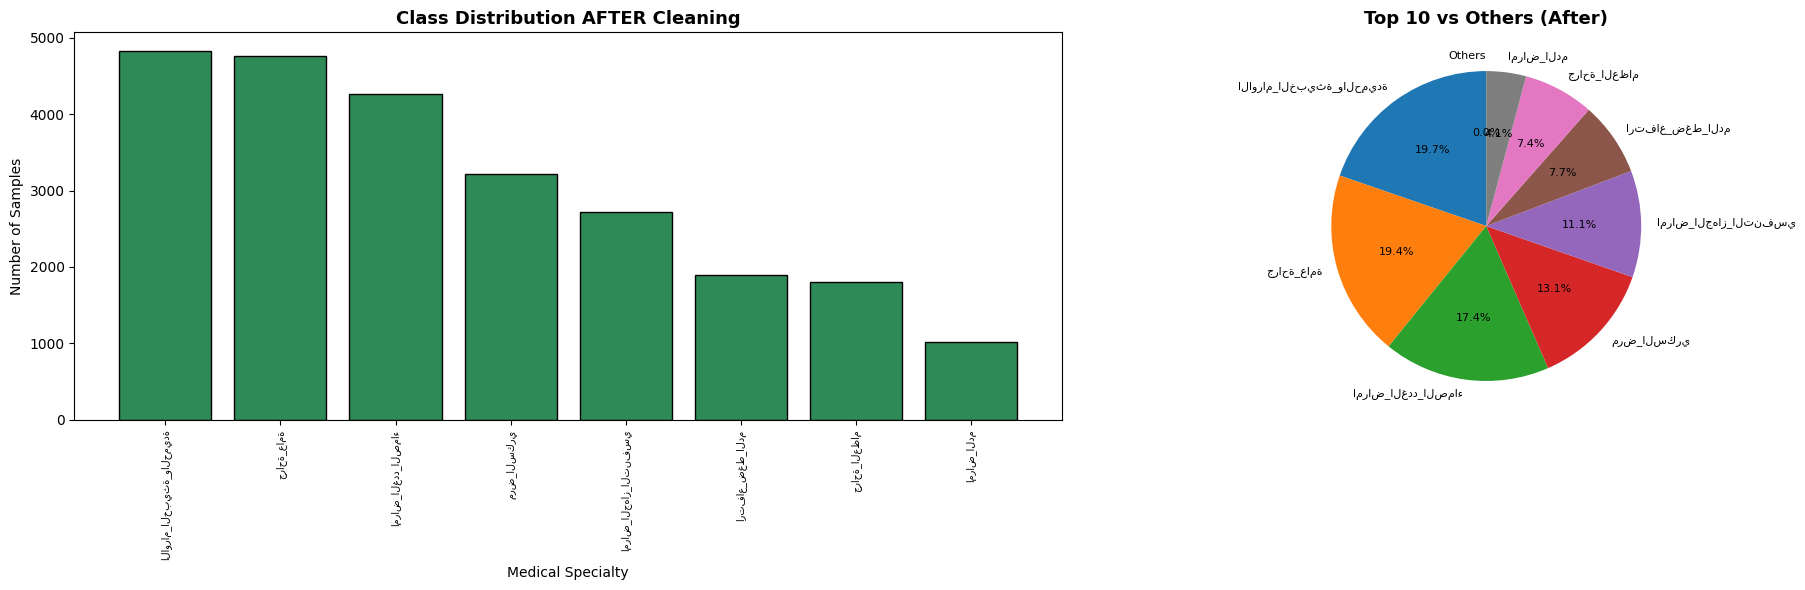

Unique labels: 8
Largest:  الاورام_الخبيثة_والحميدة = 4,831
Smallest: امراض_الدم = 1,016
Imbalance ratio: 5x

Note: Class imbalance will be handled via Class Weights inside the model.


In [16]:
label_counts_clean = train_clean['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].bar(range(len(label_counts_clean)), label_counts_clean.values,
            color='seagreen', edgecolor='black')
axes[0].set_title('Class Distribution AFTER Cleaning', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Medical Specialty')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xticks(range(len(label_counts_clean)))
axes[0].set_xticklabels([str(l) for l in label_counts_clean.index],
                         rotation=90, fontsize=7)

top10  = label_counts_clean.head(10)
others = label_counts_clean.iloc[10:].sum()
axes[1].pie(list(top10.values)+[others],
            labels=[str(l) for l in top10.index]+['Others'],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize':8})
axes[1].set_title('Top 10 vs Others (After)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{DATA_PATH}/eda_after_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Unique labels: {train_clean['label'].nunique()}")
print(f"Largest:  {label_counts_clean.index[0]} = {label_counts_clean.iloc[0]:,}")
print(f"Smallest: {label_counts_clean.index[-1]} = {label_counts_clean.iloc[-1]:,}")
print(f"Imbalance ratio: {label_counts_clean.iloc[0]/label_counts_clean.iloc[-1]:.0f}x")
print("\nNote: Class imbalance will be handled via Class Weights inside the model.")

## 4. Save Clean Data

In [17]:
# Clean val and test
val_clean  = val_df.drop(columns=['q_len','a_len'], errors='ignore').copy()
test_clean = test_df.drop(columns=['q_len','a_len'], errors='ignore').copy()

for df in [val_clean, test_clean]:
    df['label'] = df['label'].apply(normalize_label)
    df.dropna(subset=['question','answer','label'], inplace=True)
    df.reset_index(drop=True, inplace=True)

train_clean.to_csv(f'{DATA_PATH}/train_clean.csv', index=False, encoding='utf-8-sig')
val_clean.to_csv(f'{DATA_PATH}/val_clean.csv',     index=False, encoding='utf-8-sig')
test_clean.to_csv(f'{DATA_PATH}/test_clean.csv',   index=False, encoding='utf-8-sig')

print("Clean data saved!")
print(f"  train_clean.csv: {len(train_clean):,} rows")
print(f"  val_clean.csv:   {len(val_clean):,} rows")
print(f"  test_clean.csv:  {len(test_clean):,} rows")

Clean data saved!
  train_clean.csv: 24,499 rows
  val_clean.csv:   10,596 rows
  test_clean.csv:  10,505 rows


## 5. Cleaning Summary

In [18]:
print("=" * 60)
print("DATA CLEANING SUMMARY")
print("=" * 60)
print(f"\n1. Null & Duplicate Rows Removed:")
for name in before:
    print(f"   {name}: {before[name]:,} → {after[name]:,}")
print(f"\n2. Label Normalization:")
print(f"   Labels before: {len(label_counts_raw)}")
print(f"   Labels after:  {train_clean['label'].nunique()}")
print(f"\n3. Mislabeled Samples Removed (Cleanlab):")
print(f"   Removed: {len(train_df)-len(train_clean):,} samples")
print(f"\n4. Class Imbalance:")
print(f"   Ratio before: {label_counts_raw.iloc[0]/label_counts_raw.iloc[-1]:.0f}x")
print(f"   Ratio after:  {label_counts_clean.iloc[0]/label_counts_clean.iloc[-1]:.0f}x")
print(f"   Strategy: Class Weights inside model (next notebook)")
print(f"\n{'='*60}")
print(f"Next step: Run modeling notebook on clean data ")

DATA CLEANING SUMMARY

1. Null & Duplicate Rows Removed:
   train: 52,758 → 31,626
   val: 17,586 → 10,596
   test: 17,586 → 10,505

2. Label Normalization:
   Labels before: 37
   Labels after:  8

3. Mislabeled Samples Removed (Cleanlab):
   Removed: 7,127 samples

4. Class Imbalance:
   Ratio before: 1192x
   Ratio after:  5x
   Strategy: Class Weights inside model (next notebook)

Next step: Run modeling notebook on clean data 
